In [1]:
import torch

print(torch.__version__)

2.13.0


# what is CNN ? 

<div align="center">
<img src="img/cnni.png" width="500">
</div>

## problem
---

<div align="center">
  <img src="img/fc.webp" width="400">
</div>

### Fully connected layer (FC layer)

- 파라미터 수 너무 많음
- 공간 정보 사라짐
    - 위치 정보에 약함
- 특징 추출이 비효율적
    - 모든 위치에 대해 독립적으로 학습

## solution
---

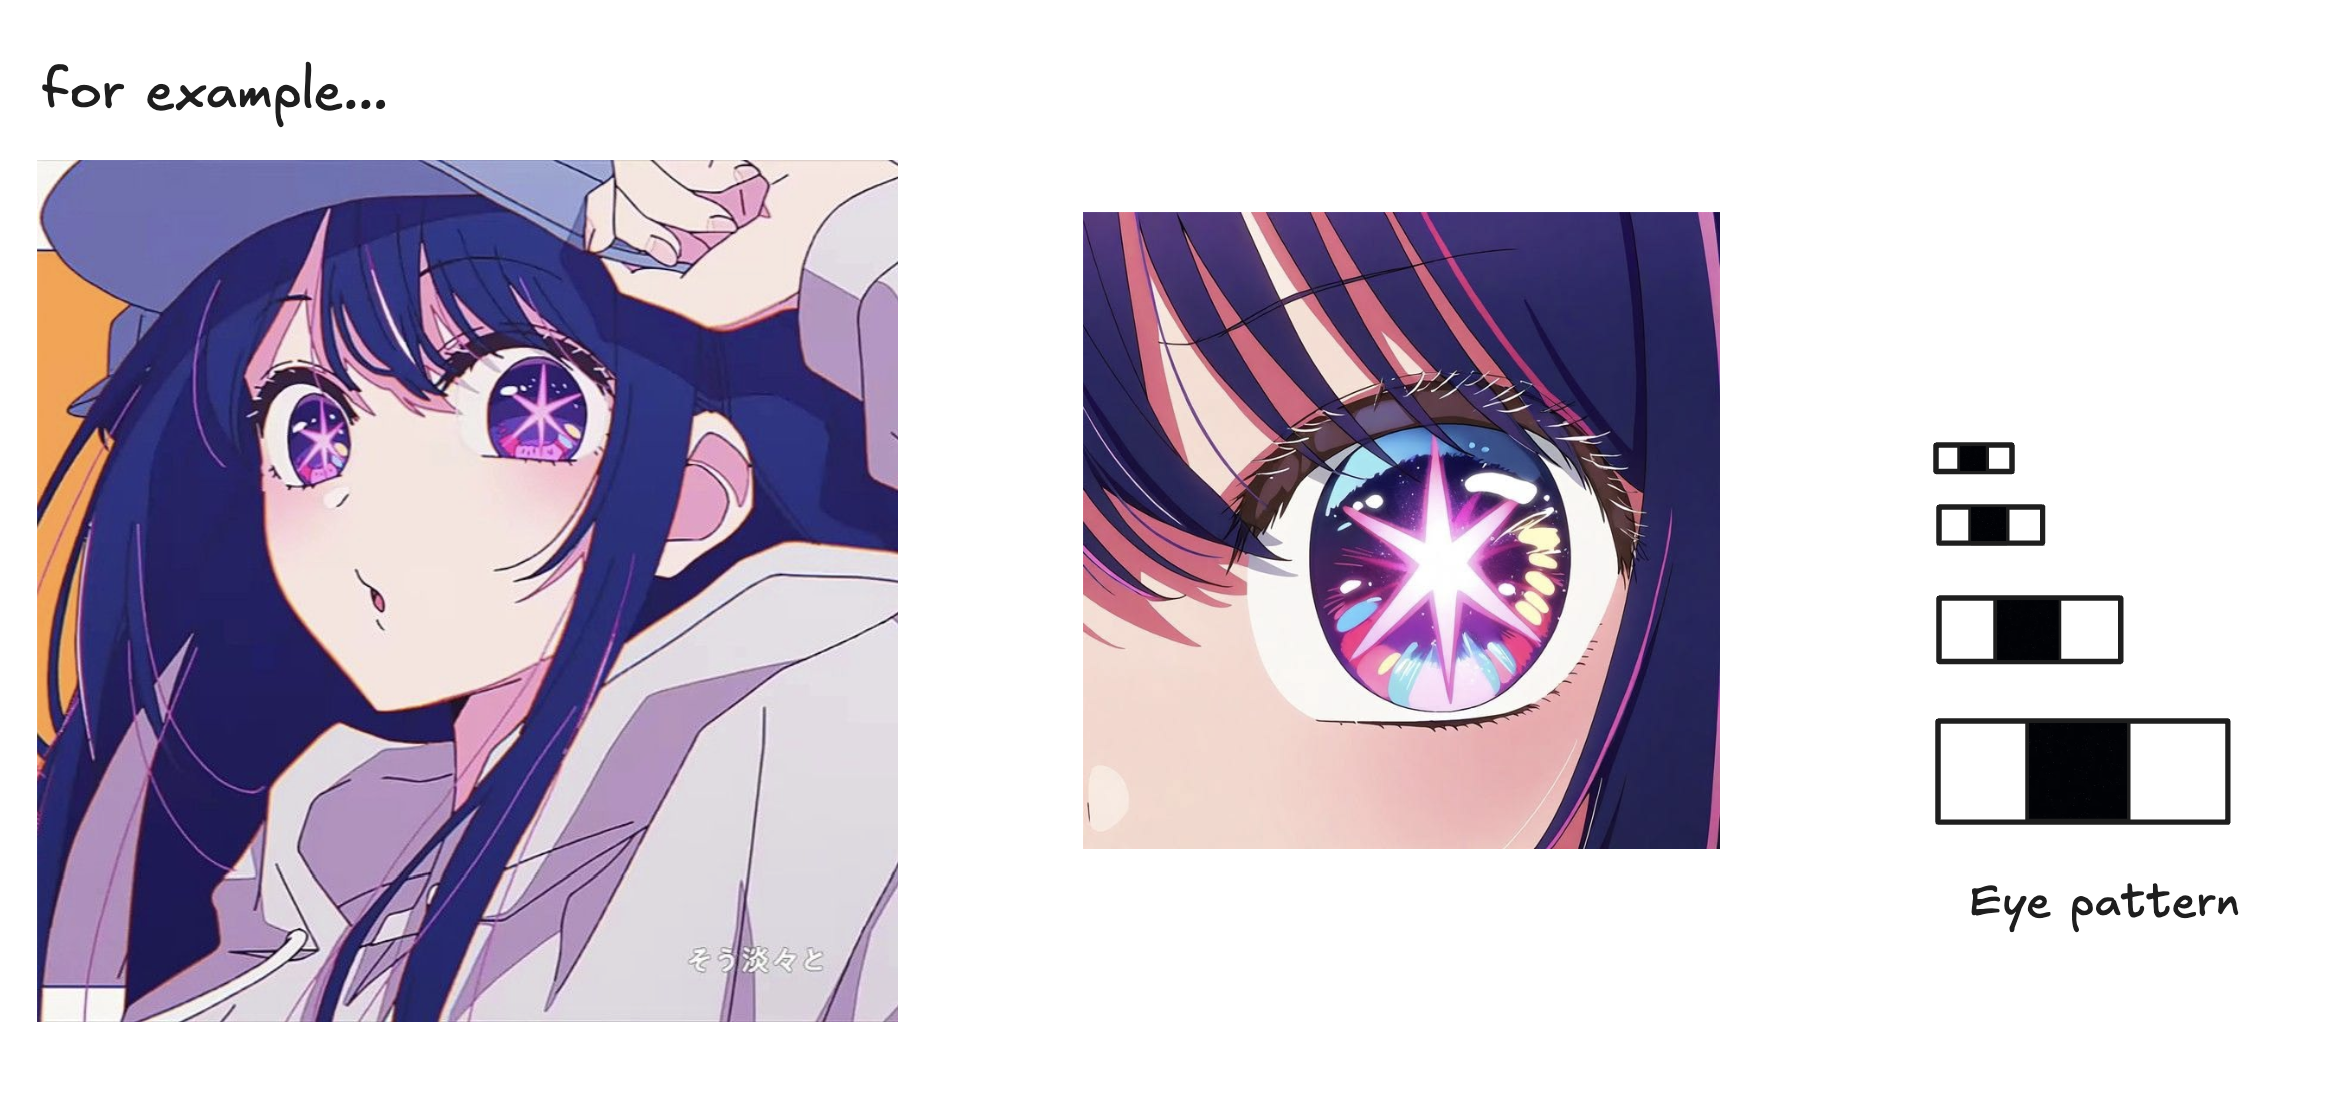

눈 패턴 찾기
1. 모든 픽셀 자리를 돌면서 스코어를 낸다.
2. 스코어가 특정 값 이상이면 그 위치가 눈 패턴이 있는 위치라고 판단한다.

## code
---

### 조건

이미지 필터가 주어지면,

- 각 위치에서 내적(inner product)을 계산하고 그 결과를 맵 형태로 반환한다.
    - matrix product 처럼 보여도 그냥 성분곱


- 목표 객체가 존재하는지 판단하기 위해 임계값(threshold)을 적용할 수 있다.

- output size
    - 각 칸에 하나씩 생기다가 n-k에서 멈춤

$$output \ size = n - k + 1$$

In [2]:
def conv(image, filter, threshold):
    # 조건
	# image size (n, n)
	# filter size : (k, k) with k << n
	
	# 아이디어
	# output size = n-k+1 
	# filter 가 순회하는 2중 for문
	# filter 가 계산하는 2중 for문

	n = len(image)
	k = len(filter)
	
	output_size = n - k + 1
	
	output = [ 
		[0 for _ in range(output_size)] 
		for _ in range(output_size) 
	]
	
	output_size = n - k + 1
	
	for i in range(output_size):
		for j in range(output_size):
			
			v = 0
			
			for ii in range(k):
				for jj in range(k):
					
					v += image[i + ii][j + jj] * filter[ii][jj]
					
				if v >= threshold:
					output[i][j] = 1
				else:
					output[i][j] = 0
				
		return output

## filter design
---

파라미터는 사람이 정하는 것이 아니라 데이터에서 정해져야 한다.

- Spatial locality (공간적 지역성)
    - 서로 가까이 있는 픽셀일수록 관련성이 높다.
    
<br>


- Positional invariance (위치 불변성)
    - 어떤 특징이 이미지의 어느 위치에 있더라도 같은 특징으로 인식해야 한다.

## Convolutional layer (Conv layer)
---

### method
filter는 이미지를 슬라이딩하면서 내적을 계산한다.
<div align="center">
  <img src="img/conv layer.png" width="400">
</div>

### channel != 1
- RGB 이미지의 경우 각 채널별로 내적을 계산하고 그 결과를 합산하여 최종 결과를 얻는다.
- filter의 채널 수는 입력 이미지의 채널 수와 동일해야 한다.

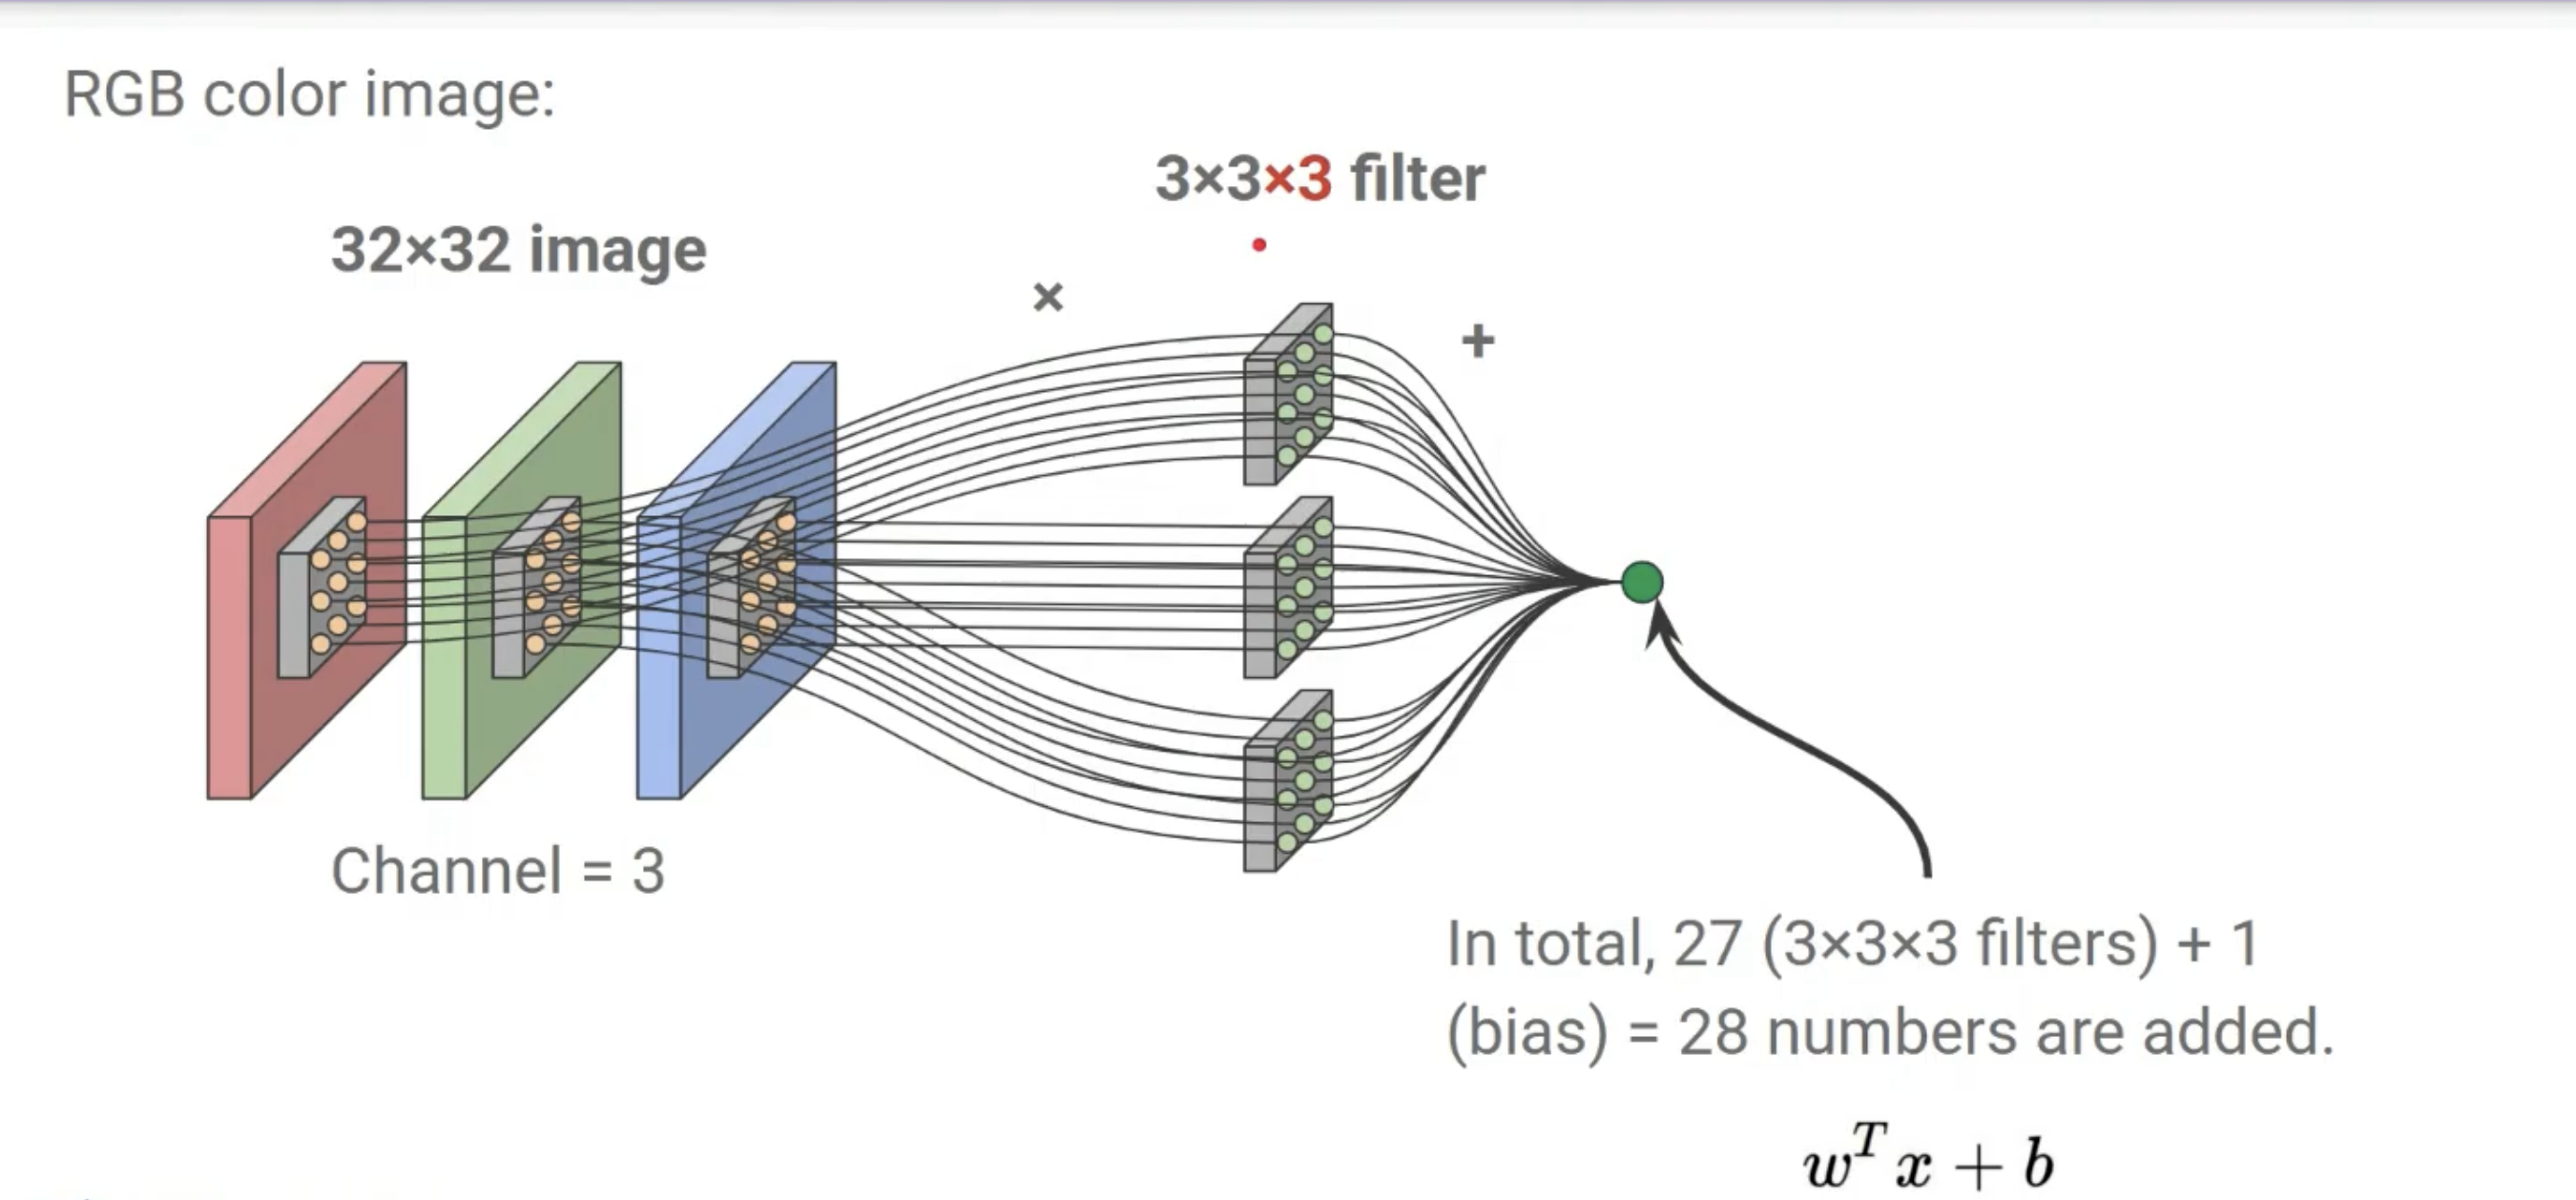

- 파라미터 개수는 filter의 사이즈 + 1이다. (bias)

### output

#### Q1

Q1. 32x32x3 이미지에 3x3x3 filter를 적용하면 output size는?


A1. 30x30x1

#### Q2

Q2. 32x32x3 이미지에 3x3x3 filter를 10개 적용하면 output size는?


A2. 30x30x10

<br>

- filter의 채널 수는 입력 이미지의 채널 수와 동일해야 한다.
- output의 채널 수는 filter의 개수와 동일하다.

## Nested conv layer
---

- 딥러닝 이전에는 왜 중첩하지 않았을까?
    - **보편 근사 정리(Universal Approximation Theorem)** 를 통해 적절한 활성화 함수를 사용하면 1개의 hidden layer만으로도 충분히 복잡한 함수를 근사할 수 있기 때문에 굳이 중첩할 필요가 없었다.

- 그렇다면 왜 딥러닝에서는 중첩을 하는가?
    - 이론상 1개의 hidden layer만으로도 충분히 복잡한 함수를 근사할 수 있지만, 실제로는 학습이 잘 되지 않는다. 따라서 여러 개의 hidden layer를 쌓아야 한다.




### two questions

1. 필터가 클수록 활성화 맵의 크기가 더 빠르게 줄어든다. 이 때문에 층을 많이 쌓기 어려운데 이를 해결할 수 있는 방법이 있을까?
2. 입력 이미지가 고해상도의 경우 합성곱 층이 너무 많은 연산을 하게 된다. 큰 이미지를 처리하는 더 좋은 방법이 있을까?

- 활성화 맵 : 필터를 적용 한 결과 (output of convolution layer)

## Stride
---

<div align="center">
  <img src="img/stride.webp" width="600">
</div>

- 문제점
    - 입력 이미지가 고해상도의 경우 합성곱 층이 너무 많은 연산을 하게 된다. 큰 이미지를 처리하는 더 좋은 방법이 있을까?


- 아이디어
    - stride를 늘려서 필터가 한 번에 이동하는 거리를 늘린다.
    - stride를 늘리면 활성화 맵의 크기가 더 빠르게 줄어든다.

$$output \ size = {(N-F)} \ / \   {stride} + 1$$

7x7 input image, 3x3 filter

- stride = 1 : (7-3) / 1 + 1 = 5
- stride = 2 : (7-3) / 2 + 1 = 3
- stride = 3 : (7-3) / 3 + 1 = 2.33



## padding
---

<div align="center">
  <img src="img/padding.png" width="600">
</div>

- 문제점
    - 필터가 클수록 활성화 맵의 크기가 더 빠르게 줄어든다. 이 때문에 층을 많이 쌓기 어려운데 이를 해결할 수 있는 방법이 있을까?

- 아이디어
    - 입력 이미지의 가장자리에 픽셀을 추가한다. 보통 0으로 채우거나 가장자리 픽셀을 복사한다.
    - 이를 통해 활성화 맵의 크기를 조절할 수 있다.

$$output \ size = (N-F+2P) / stride + 1$$

7x7 input image, 3x3 filter

- F = 3 -> P = 1
- F = 5 ->  P = 2
- F = 7 - >  P = 3 

### why conv?

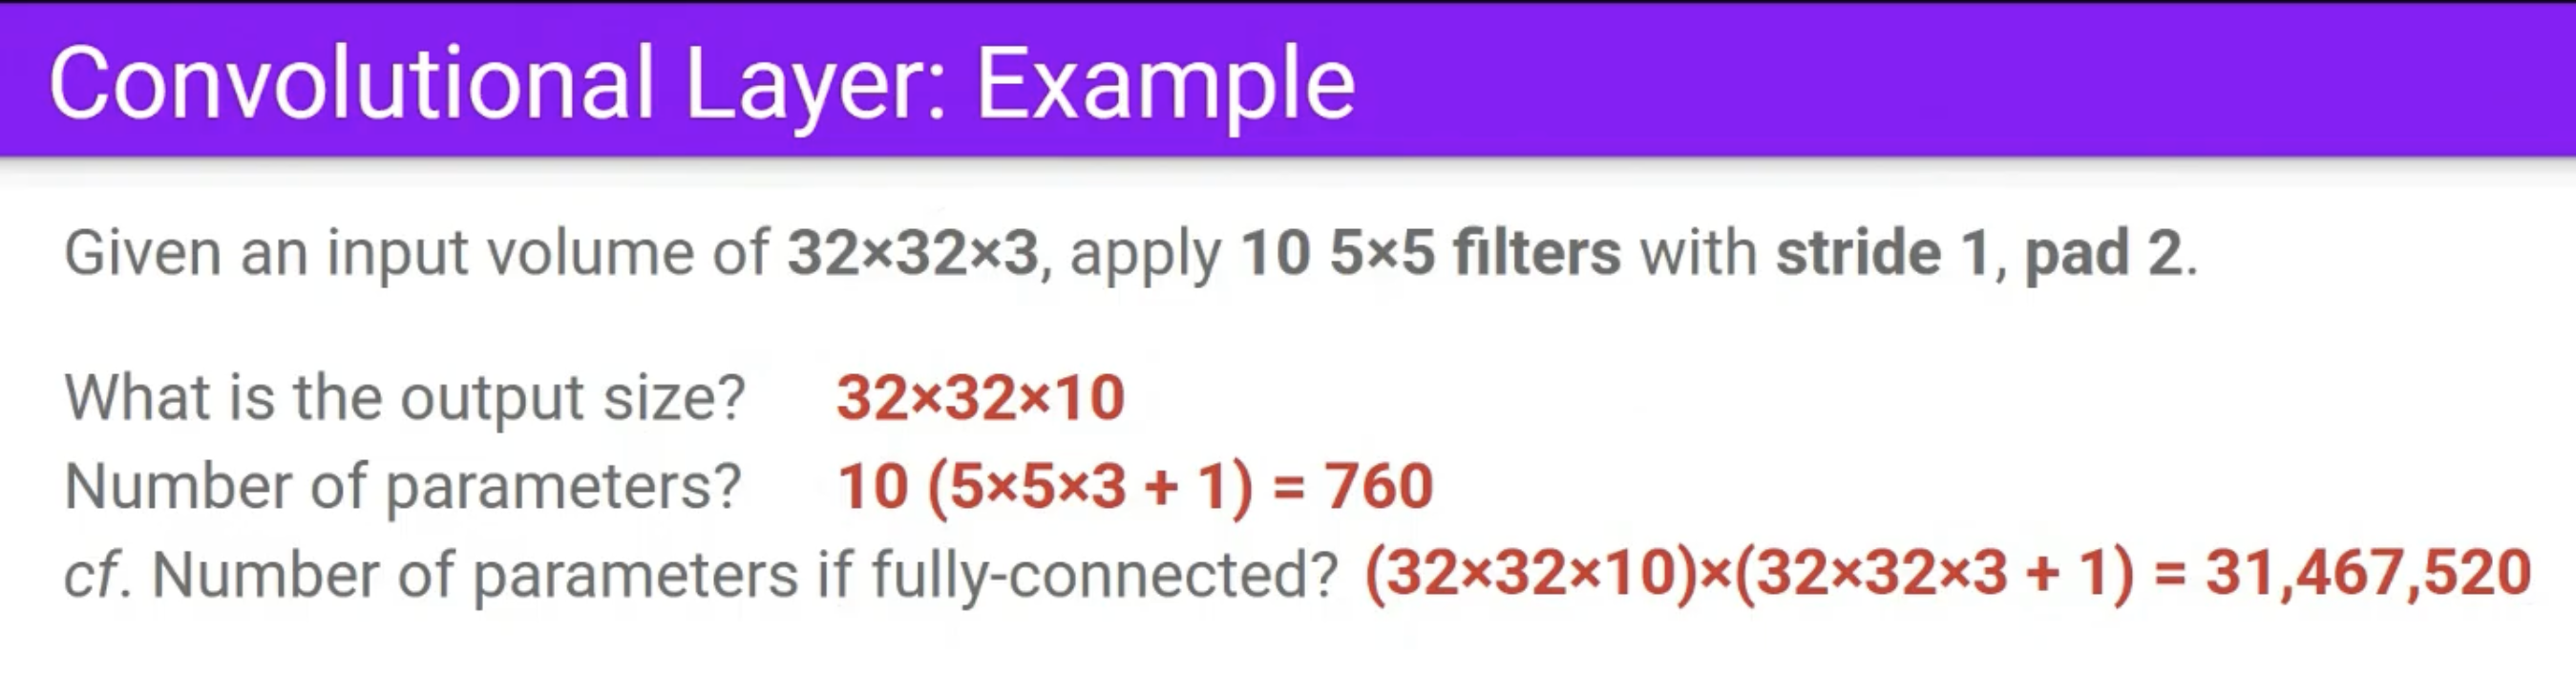

같은 크기의 input과 ouput에서 CNN과 FC layer의 파라미터 수를 비교하면 CNN이 훨씬 적다.

어떻게 이것이 가능한가?

CNN은 아래와 같은 특징을 통해 만들어졌기 때문이다.

- Spatial locality (공간적 지역성)
- Positional invariance (위치 불변성)

### why 1x1 conv?

- 채널 수를 조정 가능하기 때문이다.

예시  
- 입력이 64×64×256일 때 1×1 필터를 64개 적용하면,
    - 64 × 64 × 256 → 1×1 Conv → 64 × 64 × 64

## Summary
---

- Number of filter **K**
- The filter size **F**
- The stride **S**
- The zero padding  **P**

output of size W' x H' x K

$$W' = (W-F+2P) / S + 1$$

$$H' = (H-F+2P) / S + 1$$

$$number \ of \  parameters = K (F^2 C + 1)$$

<br>

## PyTorch
---

### Conv2d Basic Usage

```python
torch.nn.Conv2d(
    in_channels,
    out_channels,
    kernel_size,
    stride=1,
    padding=0,
    dilation=1,
    groups=1,
    bias=True,
    padding_mode='zeros',
    device=None,
    dtype=None
)
```

| 파라미터 | 설명 |
|---|---|
| in_channels | 입력 채널 수 |
| out_channels | 출력 채널 수 (필터 개수) |
| kernel_size | 필터 크기 (n x n) |
| stride | 필터 이동 간격 |
| padding | 입력 이미지 가장자리에 추가할 픽셀 수 (0으로 채워짐) |

basic usage

In [3]:
x = torch.randn(4, 3, 32, 32) # (N, C, H, W)
conv_layer = torch.nn.Conv2d(3, 5, 3, 1, 0)

print(conv_layer(x).shape) # (N, C_out, H_out, W_out)

torch.Size([4, 5, 30, 30])


floor division

In [4]:
x = torch.randn(1, 1, 8, 8) # (N, C, H, W)
# x = torch.randn(1, 8, 8)  # (C, H, W) 

conv_layer = torch.nn.Conv2d(1, 1, 3, 2, 0)

y = conv_layer(x)

# (8-3)/2+1 = 3.5 -> 3 (floor division)
print(y.shape) 

torch.Size([1, 1, 3, 3])


$$\text{출력크기} = \left\lfloor \frac{\text{입력크기} - \text{커널크기} }{\text{stride}} \right\rfloor + 1$$

'same'

In [5]:
x = torch.randn(4, 3, 32, 32) 
conv_layer = torch.nn.Conv2d(3, 5, 3, 1, 'same')

y = conv_layer(x)
print(y.shape) 

torch.Size([4, 5, 32, 32])


- stride = 1 한정, padding에 'same'을 사용 가능하다.
    - 입력과 출력의 높이, 너비가 같아지도록 패딩을 자동으로 적용한다.

## Pooling layer
---

<div align="center">
  <img src="img/pooling.png" width="600">
</div>

Pooling layer는 downsampling을 통해 특징 맵의 높이와 너비를 줄이는 층이다.

<div align="center">
  <img src="img/pooling2.png" width="300">
</div>

- Max Pooling : 가장 큰 값을 선택한다.
- Average Pooling : 평균 값을 선택한다.

### Summary

- The spatial extent F
- The stride S

output of size W' x H' x K

$$W' = (W-F) / S + 1$$
$$H' = (H-F) / S + 1$$

$$number \ of \  parameters = 0$$
$$(no  \ "learning"  \ happens)$$

## bias
---

- 필터와 입력 영역의 내적 결과에는 bias가 스칼라로 더해진다. 


<br>

$$
z_{k,i,j}
=
\sum_{c,u,v} W_{k,c,u,v}\,X_{c,i+u,j+v}
+b_k
$$

<br>

bias는 필터당 1개이기 때문에, 필터 파라미터 개수 외에도 필터수 x 1 (bias) 만큼의 파라미터 개수가 더해진다.



## Experiment
---

### 1. is CNN better than FC?

같은  파라미터 상에서 FC layer와 CNN 비교

| 지표  | 질문 |
|---|---|
| Test Accuracy | CNN은 FC보다 일반화를 더 잘하는가? |
| Train Accuracy | 같은 훈련 정확도에 도달하는 데 필요한 파라미터 수는 FC 대비 CNN이 얼마나 적은가? |
| data size | 학습 데이터가 적을수록 CNN이 FC보다 유리한가? |

### 1. 데이터셋

본 실험에서는 CIFAR-10을 사용한다.

<br>


| 구분 | 전체 데이터 대비 비율 |
|---|---:|
| Train | 75% |
| Validation | 약 8.33% |
| Test | 약 16.67% |

$$Train : Validation : Test = 9 : 1 : 2$$

<br>

데이터 양에 따른 비교를 위해 1000, 5000, 45000장을 사용한다.

### 2. 모델
### FC
```mermaid
flowchart LR
    A["입력"] --> B["Flatten"]
    B --> C["Linear + ReLU × 2"]
    C --> D["Linear(10)"]
```

### CNN
```mermaid
flowchart LR
    A["입력"] --> B["Conv + ReLU + MaxPool × 2"]
    B --> C["Flatten"]
    C --> D["Linear(10)"]
```